In [32]:
!pip install torch torchvision matplotlib

In [33]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
import torchvision
import os

In [34]:
!wget http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz
!tar -xvf facades.tar.gz

--2026-03-04 15:30:38--  http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30168306 (29M) [application/x-gzip]
Saving to: ‘facades.tar.gz.1’

facades.tar.gz.1    100%[===================>]  28.77M  5.98MB/s    in 5.8s    

2026-03-04 15:30:44 (4.93 MB/s) - ‘facades.tar.gz.1’ saved [30168306/30168306]

facades/
facades/test/
facades/test/27.jpg
facades/test/5.jpg
facades/test/72.jpg
facades/test/1.jpg
facades/test/10.jpg
facades/test/100.jpg
facades/test/101.jpg
facades/test/102.jpg
facades/test/103.jpg
facades/test/104.jpg
facades/test/105.jpg
facades/test/106.jpg
facades/test/11.jpg
facades/test/12.jpg
facades/test/13.jpg
facades/test/14.jpg
facades/test/15.jpg
facades/test/16.jpg
facades/test/17.jpg
facades/test/18.jpg
facade

In [35]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

In [36]:
from PIL import Image

class FacadesDataset(torch.utils.data.Dataset):

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.images = os.listdir(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(self.root_dir, self.images[idx])
        image = Image.open(img_path)

        w, h = image.size
        input_img = image.crop((0,0,w/2,h))
        target_img = image.crop((w/2,0,w,h))

        if self.transform:
            input_img = self.transform(input_img)
            target_img = self.transform(target_img)

        return input_img, target_img

In [37]:
dataset = FacadesDataset("facades/train", transform=transform)

dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

In [38]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(3,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):
        return self.model(x)

In [39]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(6,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,1,4,1,1),
            nn.Sigmoid()
        )

    def forward(self,x,y):

        xy = torch.cat([x,y],1)
        return self.model(xy)

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator().to(device)
D = Discriminator().to(device)

In [41]:
criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0002)

In [31]:
for epoch in range(5):

    for real_A, real_B in dataloader:

        real_A = real_A.to(device)
        real_B = real_B.to(device)

        fake_B = G(real_A)

        # Train Discriminator
        real_loss = criterion(D(real_A, real_B), torch.ones_like(D(real_A, real_B)))
        fake_loss = criterion(D(real_A, fake_B.detach()), torch.zeros_like(D(real_A, fake_B)))

        D_loss = (real_loss + fake_loss)/2

        optimizer_D.zero_grad()
        D_loss.backward()
        optimizer_D.step()

        # Train Generator
        G_loss = criterion(D(real_A, fake_B), torch.ones_like(D(real_A, fake_B)))

        optimizer_G.zero_grad()
        G_loss.backward()
        optimizer_G.step()

    print("Epoch:", epoch, "Generator Loss:", G_loss.item())

Epoch: 0 Generator Loss: 1.357671856880188
Epoch: 1 Generator Loss: 1.7325881719589233
Epoch: 2 Generator Loss: 1.9466452598571777
Epoch: 3 Generator Loss: 2.728083610534668
Epoch: 4 Generator Loss: 2.6178669929504395


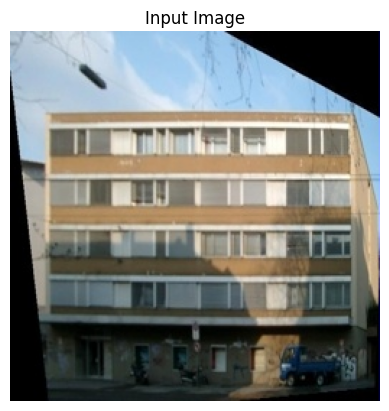

In [48]:
real_A, _ = next(iter(dataloader))

# Display the input image (real_A)
img_input = real_A[0].cpu().detach().permute(1,2,0)
plt.imshow(img_input)
plt.axis("off")
plt.title("Input Image")
plt.show()

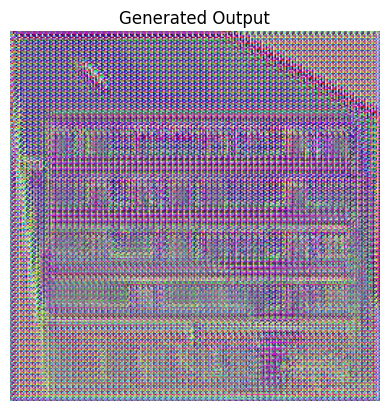

In [49]:
real_A = real_A.to(device)

# Generate output (fake_B) from the input real_A
fake_B = G(real_A)

# Scale pixel values from [-1, 1] to [0, 1] for proper display
img_output = (fake_B[0].cpu().detach().permute(1,2,0) + 1) / 2
plt.imshow(img_output)
plt.axis("off")
plt.title("Generated Output")
plt.show()

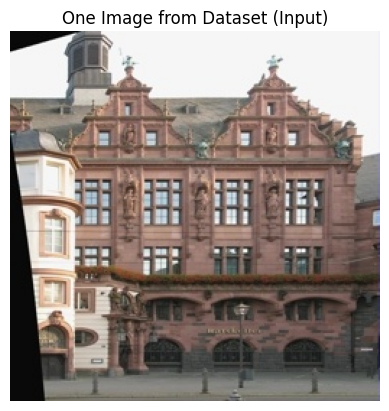

In [47]:
real_A, _ = next(iter(dataloader))

# Display the first real_A image from the batch
# Scale pixel values from [-1, 1] to [0, 1] for proper display, if applicable
img_display = real_A[0].cpu().detach().permute(1,2,0)

# Assuming the dataset images are already in [0,1] or a similar range for imshow,
# if not, an additional scaling like `(img_display + 1) / 2` might be needed depending on the transform.
plt.imshow(img_display)
plt.axis("off")
plt.title("One Image from Dataset (Input)")
plt.show()

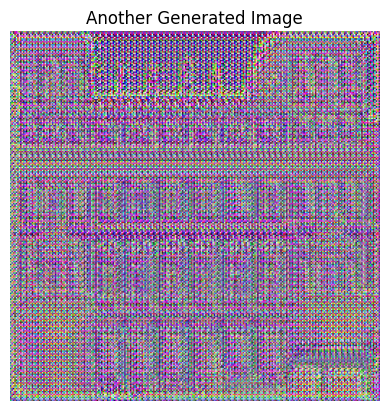

In [46]:
real_A, real_B = next(iter(dataloader))

real_A = real_A.to(device)

fake_B = G(real_A)

# Scale pixel values from [-1, 1] to [0, 1] for proper display
img_output = (fake_B[0].cpu().detach().permute(1,2,0) + 1) / 2

plt.imshow(img_output)
plt.axis("off")
plt.title("Another Generated Image")
plt.show()

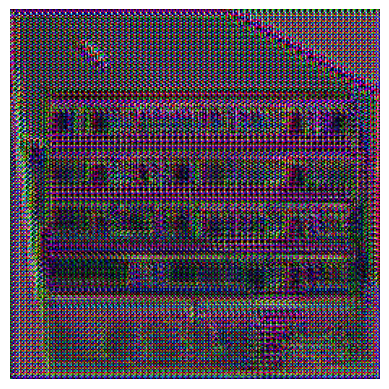

In [42]:
real_A, real_B = next(iter(dataloader))

real_A = real_A.to(device)

fake_B = G(real_A)

img = fake_B[0].cpu().detach().permute(1,2,0)

plt.imshow(img)
plt.axis("off")
plt.show()

In [43]:
!wget https://people.eecs.berkeley.edu/~tinghuiz/projects/pix2pix/datasets/facades.tar.gz

--2026-03-04 15:30:45--  https://people.eecs.berkeley.edu/~tinghuiz/projects/pix2pix/datasets/facades.tar.gz
Resolving people.eecs.berkeley.edu (people.eecs.berkeley.edu)... 128.32.244.190
Connecting to people.eecs.berkeley.edu (people.eecs.berkeley.edu)|128.32.244.190|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://tinghuiz.github.io/projects/pix2pix/datasets/facades.tar.gz [following]
--2026-03-04 15:30:45--  https://tinghuiz.github.io/projects/pix2pix/datasets/facades.tar.gz
Resolving tinghuiz.github.io (tinghuiz.github.io)... 185.199.110.153, 185.199.109.153, 185.199.111.153, ...
Connecting to tinghuiz.github.io (tinghuiz.github.io)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-04 15:30:45 ERROR 404: Not Found.



In [44]:
!tar -xvf facades.tar.gz

facades/
facades/test/
facades/test/27.jpg
facades/test/5.jpg
facades/test/72.jpg
facades/test/1.jpg
facades/test/10.jpg
facades/test/100.jpg
facades/test/101.jpg
facades/test/102.jpg
facades/test/103.jpg
facades/test/104.jpg
facades/test/105.jpg
facades/test/106.jpg
facades/test/11.jpg
facades/test/12.jpg
facades/test/13.jpg
facades/test/14.jpg
facades/test/15.jpg
facades/test/16.jpg
facades/test/17.jpg
facades/test/18.jpg
facades/test/19.jpg
facades/test/2.jpg
facades/test/20.jpg
facades/test/21.jpg
facades/test/22.jpg
facades/test/23.jpg
facades/test/24.jpg
facades/test/25.jpg
facades/test/26.jpg
facades/test/50.jpg
facades/test/51.jpg
facades/test/52.jpg
facades/test/53.jpg
facades/test/54.jpg
facades/test/55.jpg
facades/test/56.jpg
facades/test/57.jpg
facades/test/58.jpg
facades/test/59.jpg
facades/test/6.jpg
facades/test/60.jpg
facades/test/61.jpg
facades/test/62.jpg
facades/test/63.jpg
facades/test/64.jpg
facades/test/65.jpg
facades/test/66.jpg
facades/test/67.jpg
facades/test/6

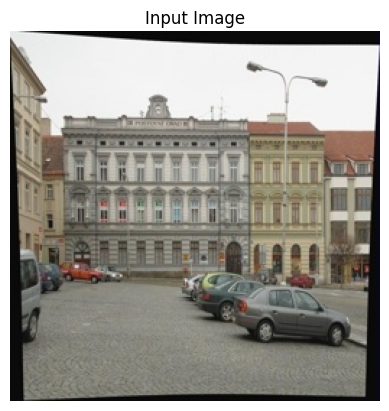

In [50]:
real_A, _ = next(iter(dataloader))

# Display the input image (real_A)
img_input = real_A[0].cpu().detach().permute(1,2,0)
plt.imshow(img_input)
plt.axis("off")
plt.title("Input Image")
plt.show()

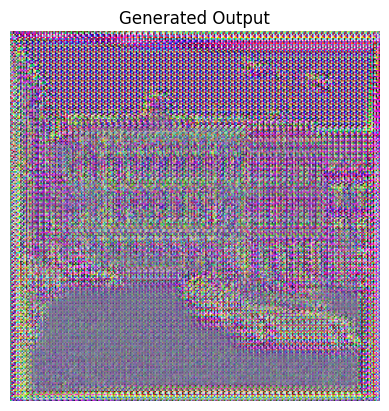

In [51]:
real_A = real_A.to(device)

# Generate output (fake_B) from the input real_A
fake_B = G(real_A)

# Scale pixel values from [-1, 1] to [0, 1] for proper display
img_output = (fake_B[0].cpu().detach().permute(1,2,0) + 1) / 2
plt.imshow(img_output)
plt.axis("off")
plt.title("Generated Output")
plt.show()